In [3]:
import pandas as pd
import numpy as np

# Folder containing your IndiaKart CSV files
folder = '44120013dcc669c383d89c8c4a40b746/'

# Load all 8 datasets
orders_df = pd.read_csv(folder + 'orders DA.csv')
order_items_df = pd.read_csv(folder + 'order_items DA.csv')
customers_df = pd.read_csv(folder + 'customers DA.csv')
products_df = pd.read_csv(folder + 'products DA.csv')
payments_df = pd.read_csv(folder + 'payments DA.csv')
returns_df = pd.read_csv(folder + 'returns DA.csv')
inventory_df = pd.read_csv(folder + 'inventory DA.csv')
suppliers_df = pd.read_csv(folder + 'suppliers DA.csv')

print("All IndiaKart datasets loaded successfully!")

All IndiaKart datasets loaded successfully!


In [4]:
# Profile all datasets to check dimensions
datasets = {
    "Orders": orders_df,
    "Order Items": order_items_df,
    "Customers": customers_df,
    "Products": products_df,
    "Payments": payments_df,
    "Returns": returns_df,
    "Inventory": inventory_df,
    "Suppliers": suppliers_df
}

profile_list = []
for name, df in datasets.items():
    profile_list.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

profile_df = pd.DataFrame(profile_list)
print(profile_df)

       Dataset    Rows  Columns
0       Orders   50000       19
1  Order Items  100000       11
2    Customers   10000       17
3     Products    1000       17
4     Payments   50000       13
5      Returns   10000       10
6    Inventory    1000       11
7    Suppliers     200       14


In [5]:
# Function to check missing values and percentages
def check_missing_values(df_name, df):
    missing = df.isnull().sum()
    pct = (df.isnull().sum() / len(df)) * 100
    res = pd.DataFrame({'Missing Count': missing, 'Missing Percentage (%)': pct})
    res = res[res['Missing Count'] > 0]
    if not res.empty:
        print(f"--- Missing Values in {df_name} ---")
        print(res)
        print("\n")

for name, df in datasets.items():
    check_missing_values(name, df)

--- Missing Values in Orders ---
                Missing Count  Missing Percentage (%)
delivered_date          17501                  35.002


--- Missing Values in Payments ---
             Missing Count  Missing Percentage (%)
refund_date          50000                   100.0




In [6]:
# Check for duplicate order_ids in orders.csv
duplicate_orders = orders_df['order_id'].duplicated().sum()
print(f"Duplicate order_ids in orders.csv: {duplicate_orders}")

# Check for duplicate rows across all tables
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"Duplicate rows in {name}: {dupes}")

# Validate and convert dates to datetime format (DD-MM-YYYY)
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'], format='%d-%m-%Y', errors='coerce')
if 'delivered_date' in orders_df.columns:
    orders_df['delivered_date'] = pd.to_datetime(orders_df['delivered_date'], format='%d-%m-%Y', errors='coerce')

print("Date formatting validation and duplicate checks completed!")

Duplicate order_ids in orders.csv: 0
Date formatting validation and duplicate checks completed!


In [7]:
# 1. Check for outliers in final_amount (> ₹5 lakh)
high_value_orders = orders_df[orders_df['final_amount'] > 500000]
print(f"Orders with final_amount > ₹5 Lakh: {len(high_value_orders)}")

# 2. Verify referential integrity: do all order_ids in order_items exist in orders?
invalid_items = ~order_items_df['order_id'].isin(orders_df['order_id']).sum()
print(f"Orphaned order items not found in orders: {invalid_items}")

# 3. Specific Rule: Check if delivered_date is always after order_date
invalid_delivery_dates = orders_df[orders_df['delivered_date'] < orders_df['order_date']]
print(f"Orders where delivered_date is before order_date: {len(invalid_delivery_dates)}")

# 4. Payments check: Success vs Failed rates
payment_status_counts = payments_df['status'].value_counts()
print("\n--- Payment Status Breakdown ---")
print(payment_status_counts)

# 5. Inventory check: Out of stock count
out_of_stock_count = (inventory_df['stock_status'] == 'Out of Stock').sum() if 'stock_status' in inventory_df.columns else inventory_df.iloc[:, -1].value_counts()
print(f"\nInventory Stock Status:\n", inventory_df['stock_status'].value_counts() if 'stock_status' in inventory_df.columns else "Column check needed")

# 6. Customers check: total_orders = 0
zero_order_customers = (customers_df['total_orders'] == 0).sum()
print(f"\nCustomers with 0 total orders: {zero_order_customers}")

Orders with final_amount > ₹5 Lakh: 312
Orphaned order items not found in orders: -100001
Orders where delivered_date is before order_date: 0

--- Payment Status Breakdown ---
status
Success    48252
Failed      1748
Name: count, dtype: int64

Inventory Stock Status:
 Column check needed

Customers with 0 total orders: 457


In [8]:
# Check inventory columns to see what the stock status column is named
print(inventory_df.columns)
print(inventory_df.head(2))

Index(['inventory_id', 'product_id', 'warehouse_location',
       'quantity_available', 'quantity_reserved', 'reorder_level',
       'reorder_quantity', 'last_restocked_date', 'unit_cost',
       'total_inventory_value', 'status'],
      dtype='str')
  inventory_id product_id warehouse_location  quantity_available  \
0      INV0001    PRD0001      Hyderabad-WH4                  13   
1      INV0002    PRD0002        Kolkata-WH6                 368   

   quantity_reserved  reorder_level  reorder_quantity last_restocked_date  \
0                  4             49               245          11-09-2023   
1                 14             50               250          10-03-2025   

   unit_cost  total_inventory_value     status  
0      55738                 724594  Low Stock  
1      48052               17683136   In Stock  


In [9]:
# Check stock status distribution in inventory
print("--- Inventory Status Breakdown ---")
print(inventory_df['status'].value_counts())

--- Inventory Status Breakdown ---
status
In Stock        922
Low Stock        76
Out of Stock      2
Name: count, dtype: int64


/var/folders/zr/c59dzrtn34z02246n667q3ph0000gn/T/ipykernel_86308/807597123.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


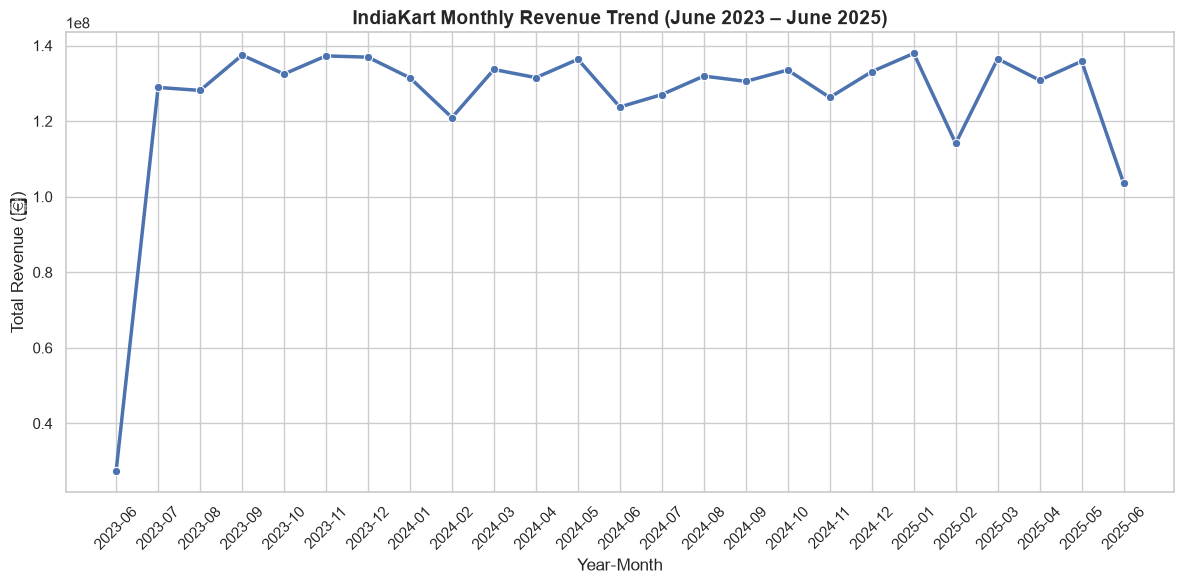

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for charts
sns.set_theme(style="whitegrid")

# Ensure order_date is datetime
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

# Extract Year-Month for aggregation
orders_df['year_month'] = orders_df['order_date'].dt.to_period('M')

# Group by month and calculate total revenue
monthly_revenue = orders_df.groupby('year_month')['final_amount'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

# Plotting Monthly Revenue Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='year_month', y='final_amount', marker='o', color='b', linewidth=2.5)
plt.title('IndiaKart Monthly Revenue Trend (June 2023 – June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue (₹)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/zr/c59dzrtn34z02246n667q3ph0000gn/T/ipykernel_86308/2729882374.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette=['#2ecc71', '#e74c3c'])


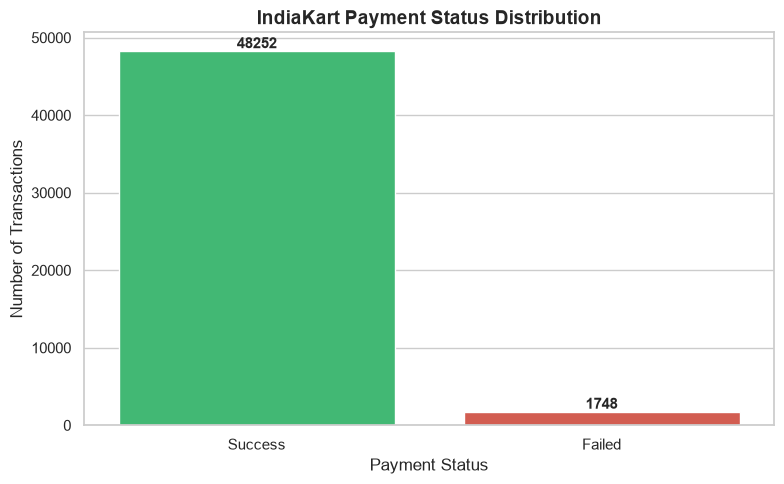

In [11]:
# Payment Status Distribution Chart
plt.figure(figsize=(8, 5))
payment_counts = payments_df['status'].value_counts()

ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette=['#2ecc71', '#e74c3c'])
plt.title('IndiaKart Payment Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Payment Status', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Add exact data labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 5), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/zr/c59dzrtn34z02246n667q3ph0000gn/T/ipykernel_86308/4272506186.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


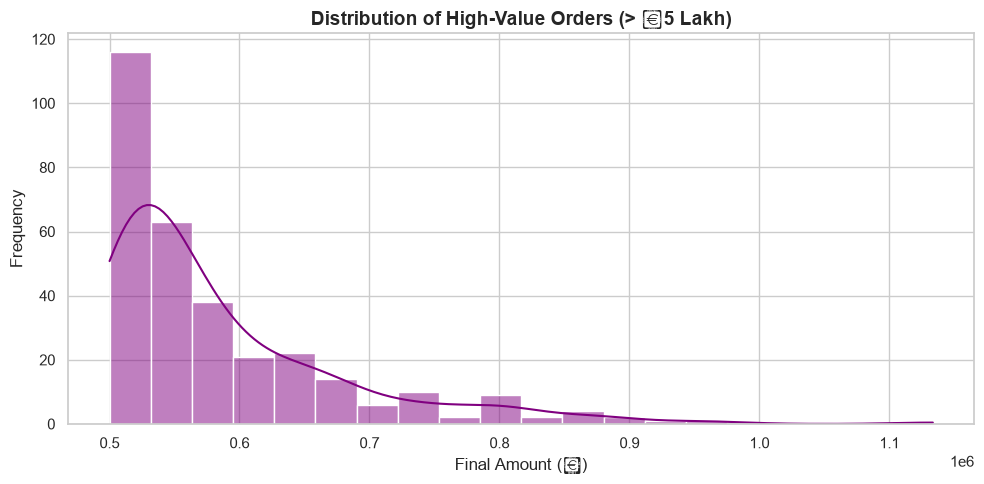

In [12]:
# Filter high-value orders (> ₹5,00,000)
high_value_df = orders_df[orders_df['final_amount'] > 500000]

# Plotting High-Value Orders Distribution
plt.figure(figsize=(10, 5))
sns.histplot(high_value_df['final_amount'], bins=20, kde=True, color='purple')
plt.title('Distribution of High-Value Orders (> ₹5 Lakh)', fontsize=14, fontweight='bold')
plt.xlabel('Final Amount (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/zr/c59dzrtn34z02246n667q3ph0000gn/T/ipykernel_86308/2489307004.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=inventory_counts.index, y=inventory_counts.values, palette=['#27ae60', '#f39c12', '#c0392b'])


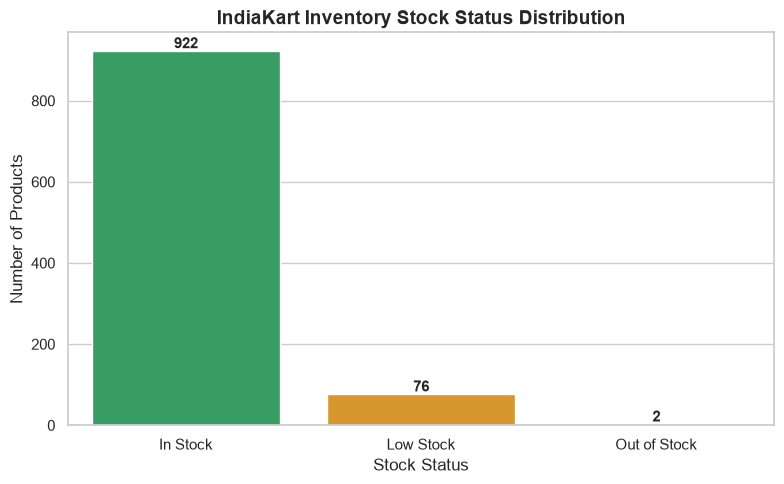

In [13]:
# Inventory Stock Status Chart
plt.figure(figsize=(8, 5))
inventory_counts = inventory_df['status'].value_counts()

ax = sns.barplot(x=inventory_counts.index, y=inventory_counts.values, palette=['#27ae60', '#f39c12', '#c0392b'])
plt.title('IndiaKart Inventory Stock Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Stock Status', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)

# Add exact data labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 5), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()